In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.chdir('/content/drive/MyDrive/transformers/projekt/')
print(f"Current working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/transformers/projekt


In [2]:
import pandas as pd

df = pd.read_csv('initial_results.csv', sep=';')
display(df.head())

,index,dataset,categorie,subcategorie,question,question_type,right_answer,first_try_answer,first_try_correct,first_try_max_prob,first_try_entropy,first_try_margin,first_try_verbal,second_try_answer,second_try_correct,second_try_max_prob,second_try_entropy,second_try_margin,second_try_verbal
0,0,strategyqa_dev,NaN,NaN,Will the Albany in Georgia reach a hundred tho...,true/false,['False'],['false'],True,99.83,99.37,1.00,85.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,strategyqa_dev,NaN,NaN,Is the language used in Saint Vincent and the ...,true/false,['True'],['true'],True,100.00,100.00,1.00,95.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,strategyqa_dev,NaN,NaN,Is greed the most prevalent of the Seven Deadl...,true/false,['False'],['false'],True,93.28,90.95,0.87,85.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,strategyqa_dev,NaN,NaN,Would the top of Mount Fuji stick out of the S...,true/false,['True'],['false'],False,99.54,98.56,0.99,95.0,['false'],False,99.09,97.54,0.98,95.0
4,4,strategyqa_dev,NaN,NaN,Was Lil Jon's top ranked Billboard song a coll...,true/false,['False'],['false'],True,99.99,99.95,1.00,95.0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.size

105963

In [4]:
first_try_verbal_varies = df['first_try_verbal'].nunique() > 1
second_try_verbal_varies = df['second_try_verbal'].nunique() > 1

print(f"'first_try_verbal' varies: {first_try_verbal_varies}")
print(f"'second_try_verbal' varies: {second_try_verbal_varies}")

'first_try_verbal' varies: True
'second_try_verbal' varies: True


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def calculate_roc_metrics(y_true, y_scores):
    """
    Calculates FPR, TPR, and AUC for a given set of true labels and prediction scores.

    Args:
        y_true (array-like): True binary labels.
        y_scores (array-like): Target scores, can either be probability estimates of the positive class,
                                 confidence values, or non-thresholded measure of decisions.

    Returns:
        tuple: (fpr, tpr, roc_auc)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

print("Libraries imported and 'calculate_roc_metrics' function defined.")

Libraries imported and 'calculate_roc_metrics' function defined.


Metrics to be plotted: ['max_prob', 'entropy', 'margin', 'verbal']

Generating ROC curve for Dataset: strategyqa_dev, Categorie: Not Categorized


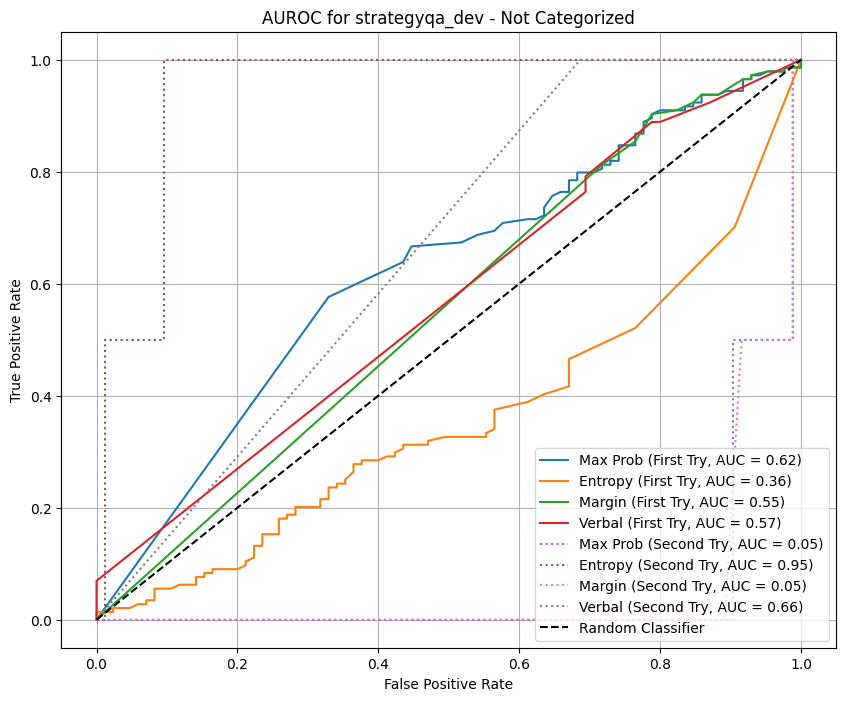


Generating ROC curve for Dataset: strategyqa_train, Categorie: Not Categorized


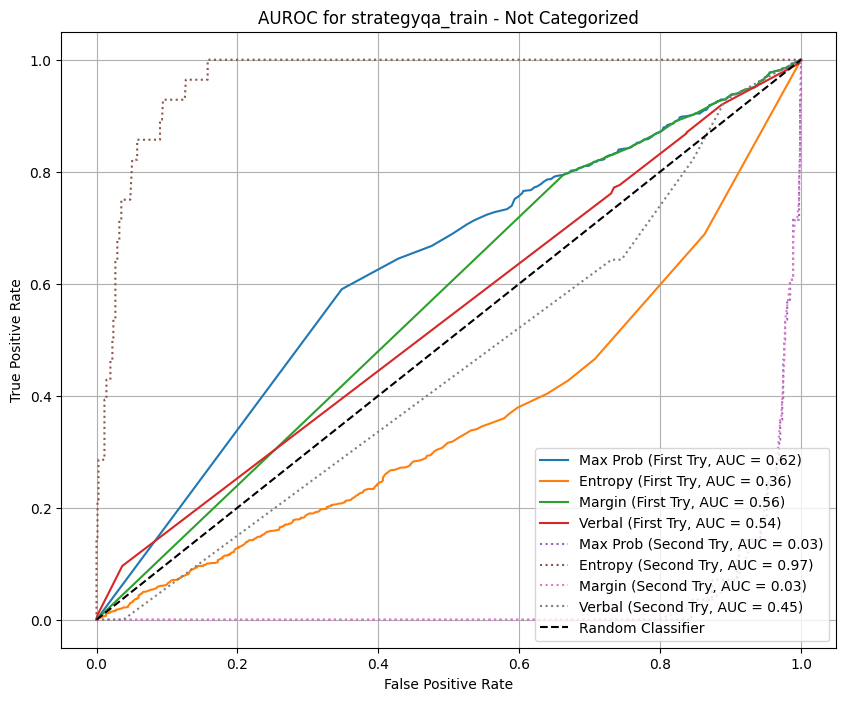


Generating ROC curve for Dataset: gsm8k_test, Categorie: math


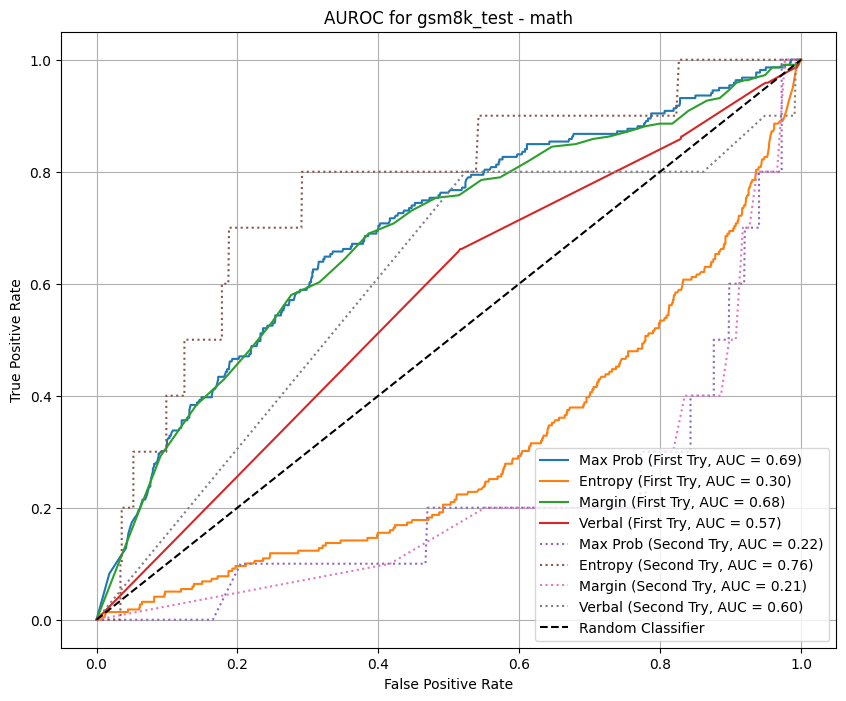


Generating ROC curve for Dataset: gsm8k_train, Categorie: math


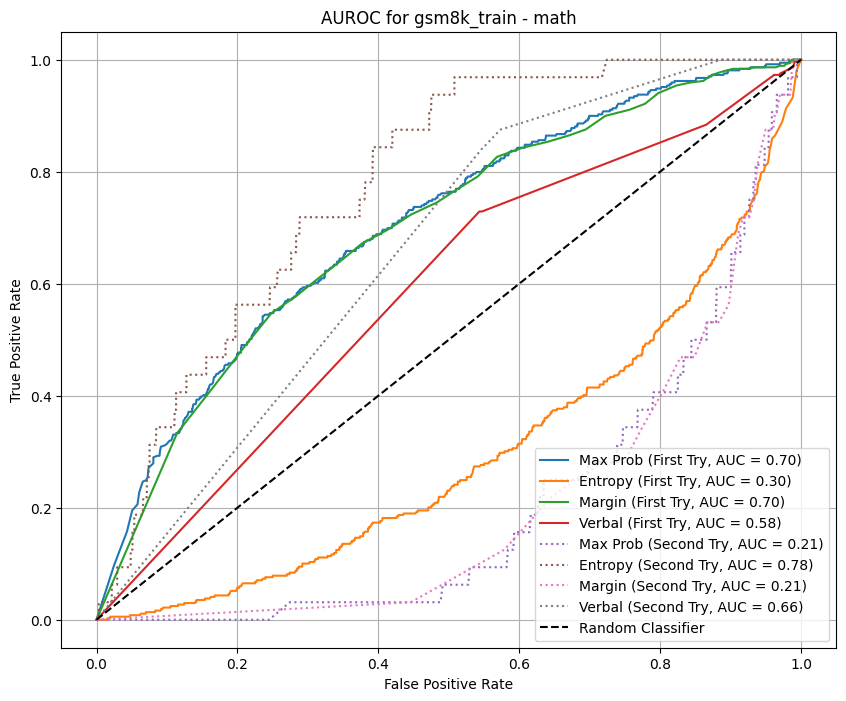

In [6]:
'''
import numpy as np

# Identify unique combinations of 'dataset' and 'categorie'
# Fill NaN 'categorie' with a placeholder string to treat them as a distinct category
df['categorie_filled'] = df['categorie'].fillna('Not Categorized')
unique_groups = df[['dataset', 'categorie_filled']].drop_duplicates().to_records(index=False)

# Define the list of metrics based on the previous check
metrics = ['max_prob', 'entropy', 'margin']
if first_try_verbal_varies or second_try_verbal_varies:
    metrics.append('verbal')

print(f"Metrics to be plotted: {metrics}")

# Iterate through each unique 'dataset' and 'categorie' combination
for dataset, categorie in unique_groups:
    print(f"\nGenerating ROC curve for Dataset: {dataset}, Categorie: {categorie}")

    # Filter the DataFrame for the current group
    df_filtered = df[(df['dataset'] == dataset) & (df['categorie_filled'] == categorie)].copy()

    if df_filtered.empty:
        print(f"No data for Dataset: {dataset}, Categorie: {categorie}. Skipping.")
        continue

    # Check if 'first_try_correct' or 'second_try_correct' contains non-binary values or only one class
    # This can happen if, for example, all values are the same (0 or 1), or if there are NaNs after filtering
    # Convert correct columns to integer type (0 or 1) for ROC curve calculation
    df_filtered['first_try_correct'] = df_filtered['first_try_correct'].astype(float).fillna(0).astype(int)
    df_filtered['second_try_correct'] = df_filtered['second_try_correct'].astype(float).fillna(0).astype(int)

    if df_filtered['first_try_correct'].nunique() < 2 or df_filtered['second_try_correct'].nunique() < 2:
        print(f"Skipping {dataset} - {categorie} due to insufficient classes in 'correct' labels for ROC curve calculation.")
        continue

    # Create a new matplotlib figure and axes for plotting
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # --- Plotting for 'first_try' metrics ---
    # y_true_first = df_filtered['first_try_correct'] # No longer needed, as it's processed inside loop
    for metric in metrics:
        score_col = f'first_try_{metric}'
        if score_col not in df_filtered.columns:
            print(f"Skipping missing column: {score_col}")
            continue

        # Ensure scores are numeric and handle potential NaNs (e.g., drop rows or fill with mean/median)
        # For ROC, it's often better to drop NaNs if they can't be meaningfully imputed
        temp_df = df_filtered[[score_col, 'first_try_correct']].dropna()
        if temp_df.empty or temp_df['first_try_correct'].nunique() < 2:
            print(f"Skipping {metric} (First Try) for {dataset} - {categorie} due to insufficient data or classes after dropping NaNs.")
            continue

        y_true = temp_df['first_try_correct']
        y_scores = temp_df[score_col]

        # Invert entropy scores for ROC if applicable (higher confidence should mean higher score)
        if metric == 'entropy':
            y_scores = 1 - y_scores

        fpr, tpr, roc_auc = calculate_roc_metrics(y_true, y_scores)
        ax.plot(fpr, tpr, linestyle='-', label=f'{metric.replace("_", " ").title()} (First Try, AUC = {roc_auc:.2f})')

    # --- Plotting for 'second_try' metrics ---
    # y_true_second = df_filtered['second_try_correct'] # No longer needed, as it's processed inside loop
    for metric in metrics:
        score_col = f'second_try_{metric}'
        if score_col not in df_filtered.columns:
            print(f"Skipping missing column: {score_col}")
            continue

        temp_df = df_filtered[[score_col, 'second_try_correct']].dropna()
        if temp_df.empty or temp_df['second_try_correct'].nunique() < 2:
            print(f"Skipping {metric} (Second Try) for {dataset} - {categorie} due to insufficient data or classes after dropping NaNs.")
            continue

        y_true = temp_df['second_try_correct']
        y_scores = temp_df[score_col]

        if metric == 'entropy':
            y_scores = 1 - y_scores

        fpr, tpr, roc_auc = calculate_roc_metrics(y_true, y_scores)
        ax.plot(fpr, tpr, linestyle=':', label=f'{metric.replace("_", " ").title()} (Second Try, AUC = {roc_auc:.2f})')

    # Add a diagonal dashed line for a random classifier
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    # Set plot title and labels
    ax.set_title(f'AUROC for {dataset} - {categorie}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True)
    plt.show()
    '''

Metrics to be plotted: ['max_prob', 'entropy', 'margin', 'verbal']

Generating ROC curve for Dataset: strategyqa_dev, Categorie: Not Categorized


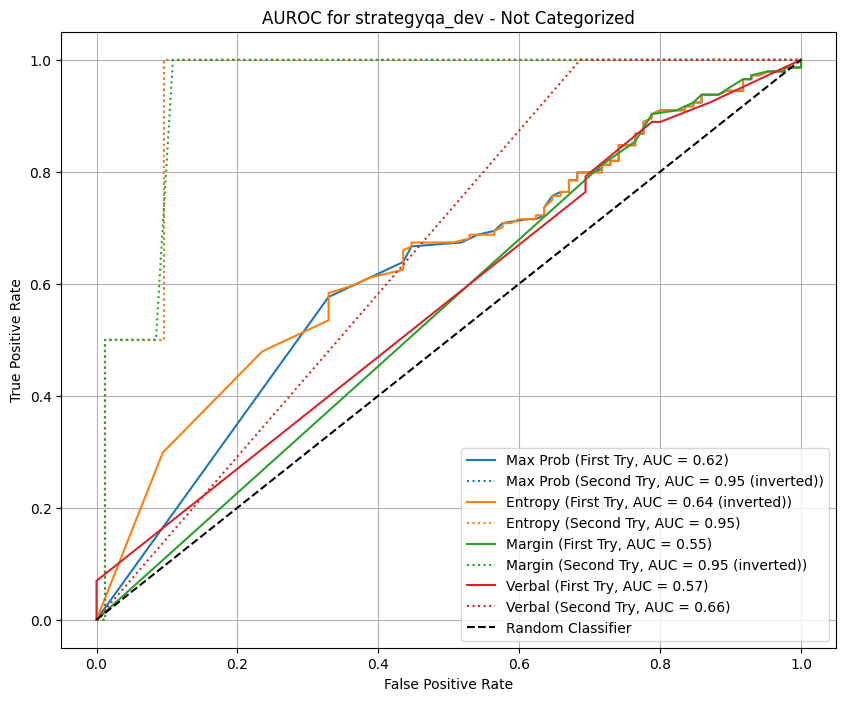


Generating ROC curve for Dataset: strategyqa_train, Categorie: Not Categorized


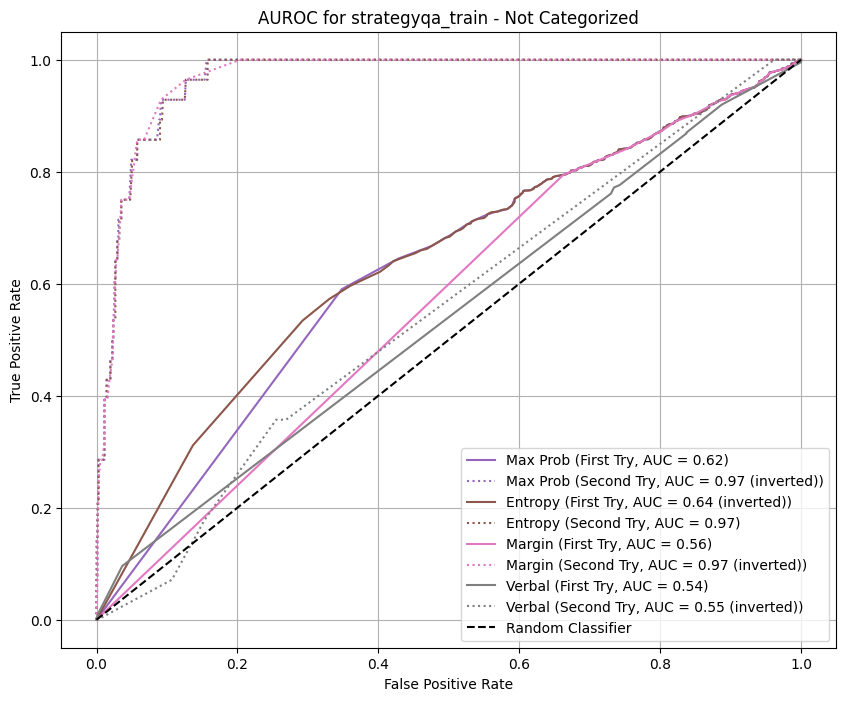


Generating ROC curve for Dataset: gsm8k_test, Categorie: math


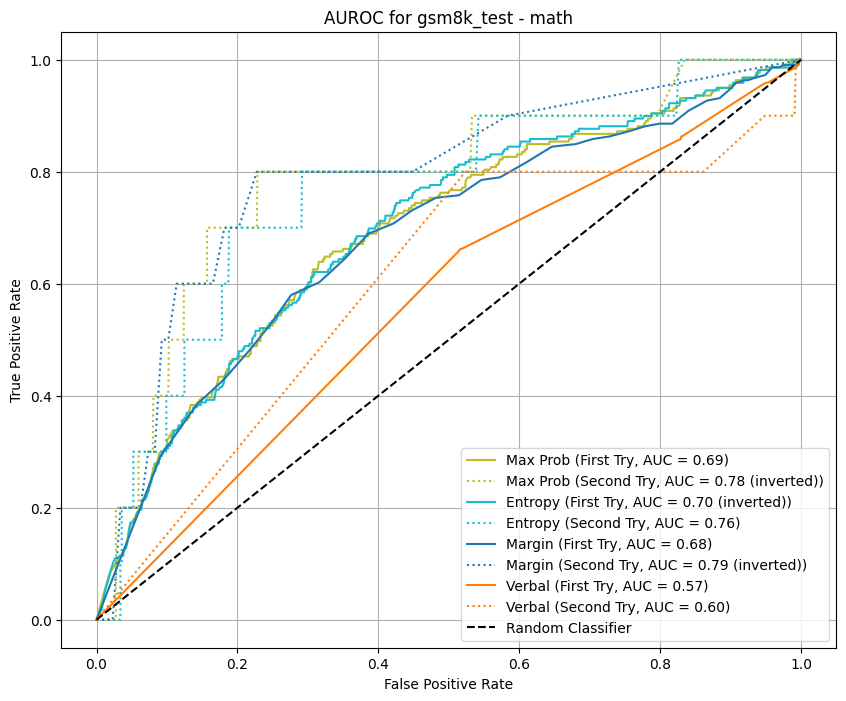


Generating ROC curve for Dataset: gsm8k_train, Categorie: math


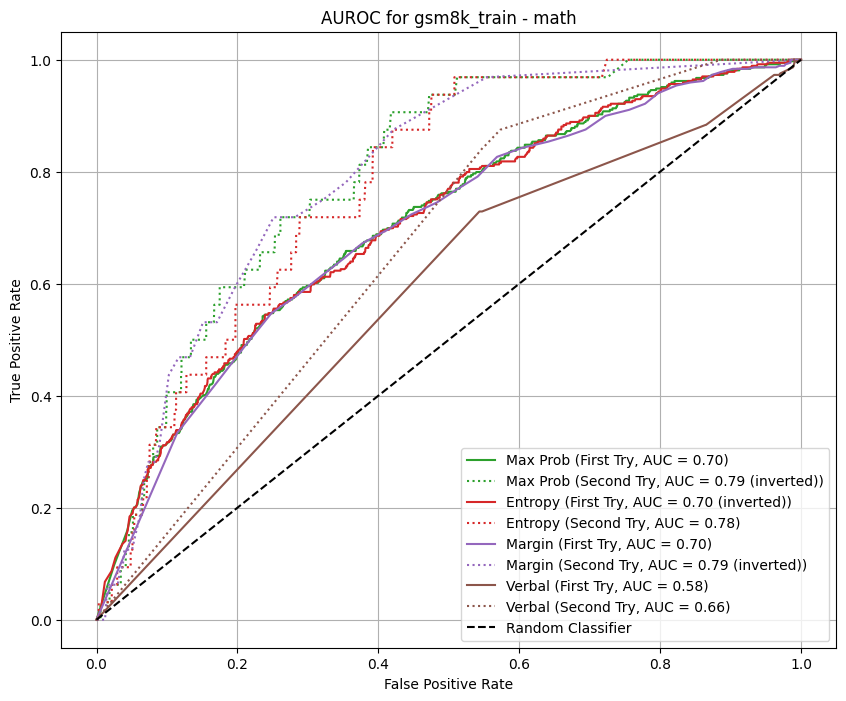

In [7]:
'''
import numpy as np
import itertools # Import itertools to cycle through colors

# Identify unique combinations of 'dataset' and 'categorie'
# Fill NaN 'categorie' with a placeholder string to treat them as a distinct category
df['categorie_filled'] = df['categorie'].fillna('Not Categorized')
unique_groups = df[['dataset', 'categorie_filled']].drop_duplicates().to_records(index=False)

# Define the list of metrics based on the previous check
metrics = ['max_prob', 'entropy', 'margin']
if first_try_verbal_varies or second_try_verbal_varies:
    metrics.append('verbal')

print(f"Metrics to be plotted: {metrics}")

# Get the default color cycle
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = itertools.cycle(default_colors)

# Iterate through each unique 'dataset' and 'categorie' combination
for dataset, categorie in unique_groups:
    print(f"\nGenerating ROC curve for Dataset: {dataset}, Categorie: {categorie}")

    # Filter the DataFrame for the current group
    df_filtered = df[(df['dataset'] == dataset) & (df['categorie_filled'] == categorie)].copy()

    if df_filtered.empty:
        print(f"No data for Dataset: {dataset}, Categorie: {categorie}. Skipping.")
        continue

    # Convert correct columns to integer type (0 or 1) for ROC curve calculation
    df_filtered['first_try_correct'] = df_filtered['first_try_correct'].astype(float).fillna(0).astype(int)
    df_filtered['second_try_correct'] = df_filtered['second_try_correct'].astype(float).fillna(0).astype(int)

    if df_filtered['first_try_correct'].nunique() < 2 or df_filtered['second_try_correct'].nunique() < 2:
        print(f"Skipping {dataset} - {categorie} due to insufficient classes in 'correct' labels for ROC curve calculation.")
        continue

    # Create a new matplotlib figure and axes for plotting
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    # Iterate through each metric, assigning a color for both tries
    for metric in metrics:
        current_color = next(color_cycle) # Get a new color for each metric

        # --- Process 'first_try' metrics ---
        score_col_first = f'first_try_{metric}'
        if score_col_first not in df_filtered.columns:
            print(f"Skipping missing column: {score_col_first}")
            continue

        temp_df_first = df_filtered[[score_col_first, 'first_try_correct']].dropna()
        if temp_df_first.empty or temp_df_first['first_try_correct'].nunique() < 2:
            print(f"Skipping {metric} (First Try) for {dataset} - {categorie} due to insufficient data or classes after dropping NaNs.")
            continue

        y_true_first = temp_df_first['first_try_correct']
        y_scores_first = temp_df_first[score_col_first].copy() # Use .copy() to avoid SettingWithCopyWarning

        label_suffix_first = ""

        # Invert entropy scores initially if applicable
        if metric == 'entropy':
            y_scores_first = 1 - y_scores_first

        # Calculate initial AUC to check for inversion condition (after entropy inversion if applicable)
        fpr_init_first, tpr_init_first, roc_auc_init_first = calculate_roc_metrics(y_true_first, y_scores_first)

        # Conditionally invert if AUC is less than 0.5
        if roc_auc_init_first < 0.5:
            y_scores_first = 1 - y_scores_first
            label_suffix_first = " (inverted)"

        # Recalculate FPR, TPR, and AUC with the final scores
        fpr_first, tpr_first, roc_auc_first = calculate_roc_metrics(y_true_first, y_scores_first)
        ax.plot(fpr_first, tpr_first, linestyle='-', color=current_color,
                label=f'{metric.replace("_", " ").title()} (First Try, AUC = {roc_auc_first:.2f}{label_suffix_first})')

        # --- Process 'second_try' metrics ---
        score_col_second = f'second_try_{metric}'
        if score_col_second not in df_filtered.columns:
            print(f"Skipping missing column: {score_col_second}")
            continue

        temp_df_second = df_filtered[[score_col_second, 'second_try_correct']].dropna()
        if temp_df_second.empty or temp_df_second['second_try_correct'].nunique() < 2:
            print(f"Skipping {metric} (Second Try) for {dataset} - {categorie} due to insufficient data or classes after dropping NaNs.")
            continue

        y_true_second = temp_df_second['second_try_correct']
        y_scores_second = temp_df_second[score_col_second].copy()

        label_suffix_second = ""

        # Invert entropy scores initially if applicable
        if metric == 'entropy':
            y_scores_second = 1 - y_scores_second

        # Calculate initial AUC to check for inversion condition (after entropy inversion if applicable)
        fpr_init_second, tpr_init_second, roc_auc_init_second = calculate_roc_metrics(y_true_second, y_scores_second)

        # Conditionally invert if AUC is less than 0.5
        if roc_auc_init_second < 0.5:
            y_scores_second = 1 - y_scores_second
            label_suffix_second = " (inverted)"

        # Recalculate FPR, TPR, and AUC with the final scores
        fpr_second, tpr_second, roc_auc_second = calculate_roc_metrics(y_true_second, y_scores_second)
        ax.plot(fpr_second, tpr_second, linestyle=':', color=current_color,
                label=f'{metric.replace("_", " ").title()} (Second Try, AUC = {roc_auc_second:.2f}{label_suffix_second})')

    # Add a diagonal dashed line for a random classifier
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    # Set plot title and labels
    ax.set_title(f'AUROC for {dataset} - {categorie}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True)
    plt.show()
    '''

Metrics to be plotted: ['max_prob', 'entropy', 'margin', 'verbal']
Metric colors mapping: {'max_prob': 'blue', 'entropy': 'orange', 'margin': 'green', 'verbal': 'red'}

Generating ROC curve for Dataset: strategyqa_dev, Categorie: Not Categorized


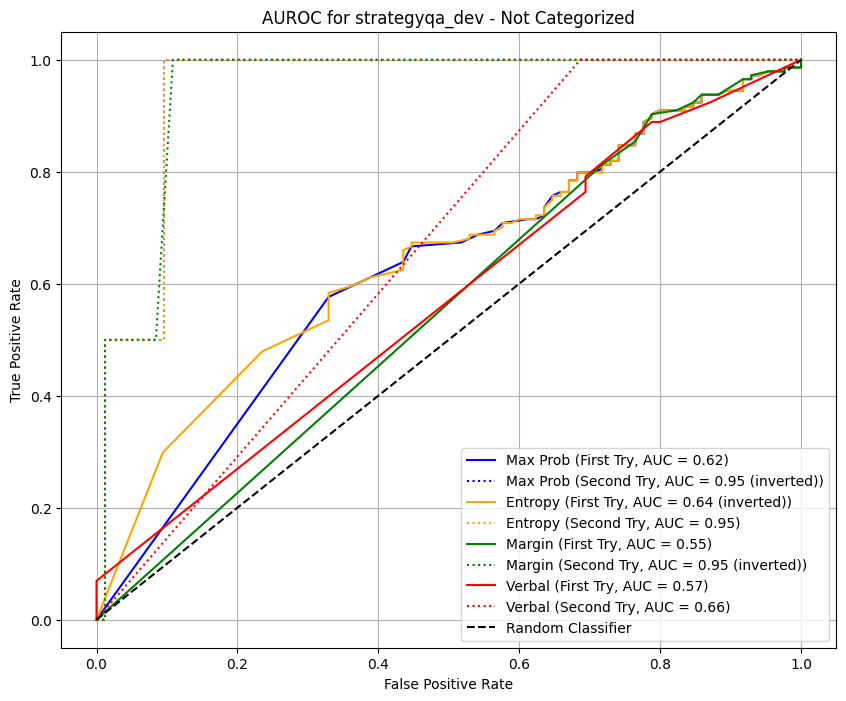


Generating ROC curve for Dataset: strategyqa_train, Categorie: Not Categorized


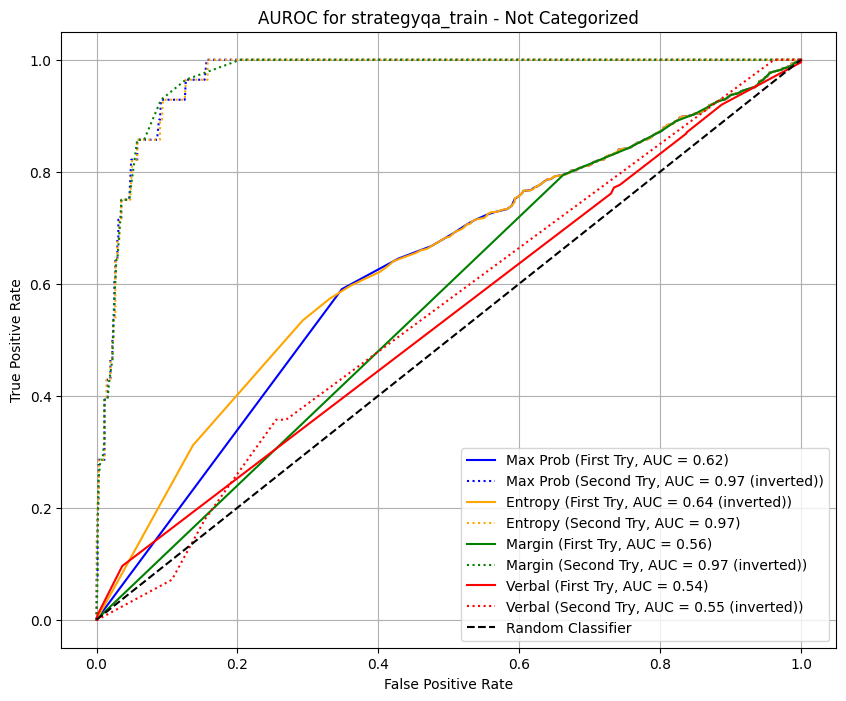


Generating ROC curve for Dataset: gsm8k_test, Categorie: math


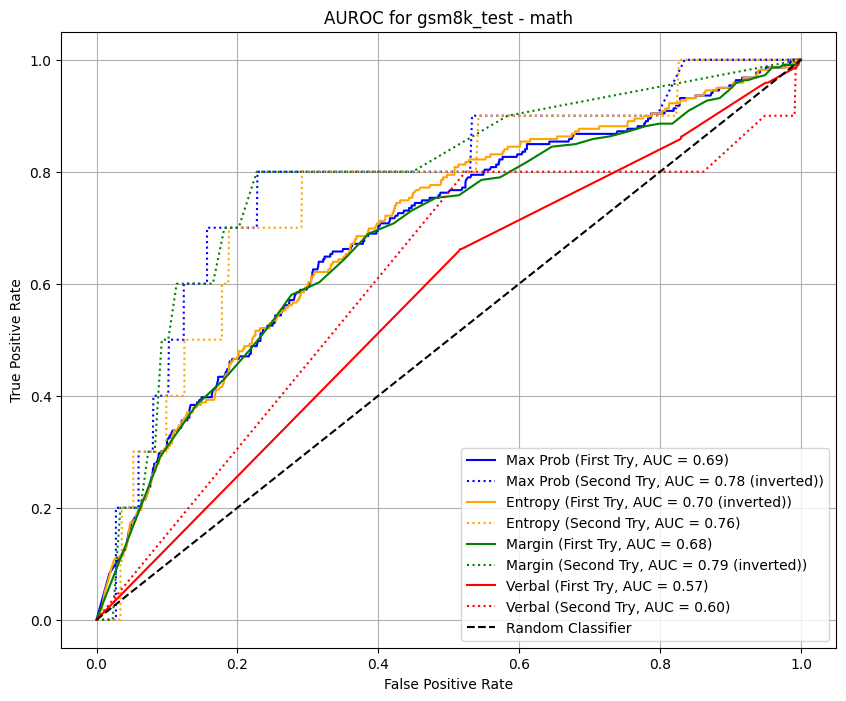


Generating ROC curve for Dataset: gsm8k_train, Categorie: math


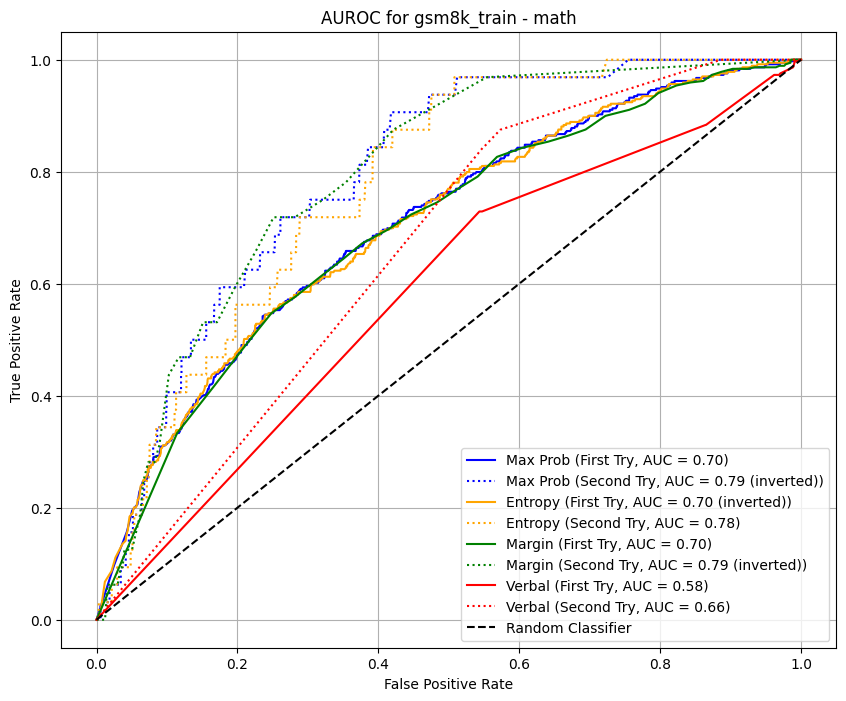

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define fixed colors for metrics (same across all plots)
fixed_colors = ['blue', 'orange', 'green', 'red']  # Add more if you have more metrics

# Identify unique combinations of 'dataset' and 'categorie'
df['categorie_filled'] = df['categorie'].fillna('Not Categorized')
unique_groups = df[['dataset', 'categorie_filled']].drop_duplicates().to_records(index=False)

# Define the list of metrics
metrics = ['max_prob', 'entropy', 'margin']
if first_try_verbal_varies or second_try_verbal_varies:
    metrics.append('verbal')

# Map each metric to a fixed color
metric_colors = {metric: fixed_colors[i % len(fixed_colors)] for i, metric in enumerate(metrics)}

print(f"Metrics to be plotted: {metrics}")
print(f"Metric colors mapping: {metric_colors}")

# Iterate through each unique dataset and categorie combination
for dataset, categorie in unique_groups:
    print(f"\nGenerating ROC curve for Dataset: {dataset}, Categorie: {categorie}")

    df_filtered = df[(df['dataset'] == dataset) & (df['categorie_filled'] == categorie)].copy()

    if df_filtered.empty:
        print(f"No data for Dataset: {dataset}, Categorie: {categorie}. Skipping.")
        continue

    # Convert correct columns to integer type (0 or 1)
    df_filtered['first_try_correct'] = df_filtered['first_try_correct'].astype(float).fillna(0).astype(int)
    df_filtered['second_try_correct'] = df_filtered['second_try_correct'].astype(float).fillna(0).astype(int)

    if df_filtered['first_try_correct'].nunique() < 2 or df_filtered['second_try_correct'].nunique() < 2:
        print(f"Skipping {dataset} - {categorie} due to insufficient classes in 'correct' labels for ROC curve calculation.")
        continue

    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    for metric in metrics:
        current_color = metric_colors[metric]  # Use fixed color

        # --- First Try ---
        score_col_first = f'first_try_{metric}'
        if score_col_first in df_filtered.columns:
            temp_df_first = df_filtered[[score_col_first, 'first_try_correct']].dropna()
            if not temp_df_first.empty and temp_df_first['first_try_correct'].nunique() > 1:
                y_true_first = temp_df_first['first_try_correct']
                y_scores_first = temp_df_first[score_col_first].copy()
                label_suffix_first = ""

                if metric == 'entropy':
                    y_scores_first = 1 - y_scores_first

                fpr_init_first, tpr_init_first, roc_auc_init_first = calculate_roc_metrics(y_true_first, y_scores_first)
                if roc_auc_init_first < 0.5:
                    y_scores_first = 1 - y_scores_first
                    label_suffix_first = " (inverted)"

                fpr_first, tpr_first, roc_auc_first = calculate_roc_metrics(y_true_first, y_scores_first)
                ax.plot(fpr_first, tpr_first, linestyle='-', color=current_color,
                        label=f'{metric.replace("_", " ").title()} (First Try, AUC = {roc_auc_first:.2f}{label_suffix_first})')

        # --- Second Try ---
        score_col_second = f'second_try_{metric}'
        if score_col_second in df_filtered.columns:
            temp_df_second = df_filtered[[score_col_second, 'second_try_correct']].dropna()
            if not temp_df_second.empty and temp_df_second['second_try_correct'].nunique() > 1:
                y_true_second = temp_df_second['second_try_correct']
                y_scores_second = temp_df_second[score_col_second].copy()
                label_suffix_second = ""

                if metric == 'entropy':
                    y_scores_second = 1 - y_scores_second

                fpr_init_second, tpr_init_second, roc_auc_init_second = calculate_roc_metrics(y_true_second, y_scores_second)
                if roc_auc_init_second < 0.5:
                    y_scores_second = 1 - y_scores_second
                    label_suffix_second = " (inverted)"

                fpr_second, tpr_second, roc_auc_second = calculate_roc_metrics(y_true_second, y_scores_second)
                ax.plot(fpr_second, tpr_second, linestyle=':', color=current_color,
                        label=f'{metric.replace("_", " ").title()} (Second Try, AUC = {roc_auc_second:.2f}{label_suffix_second})')

    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax.set_title(f'AUROC for {dataset} - {categorie}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True)
    plt.show()
